In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap
import pickle

df = pd.read_csv('E:\DUK\S2\Predictive\Employee-Attrition-Prediction-Using-HR-Analytics\WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.duplicated().sum()

np.int64(0)

EDA

In [9]:
# Target variable distribution
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

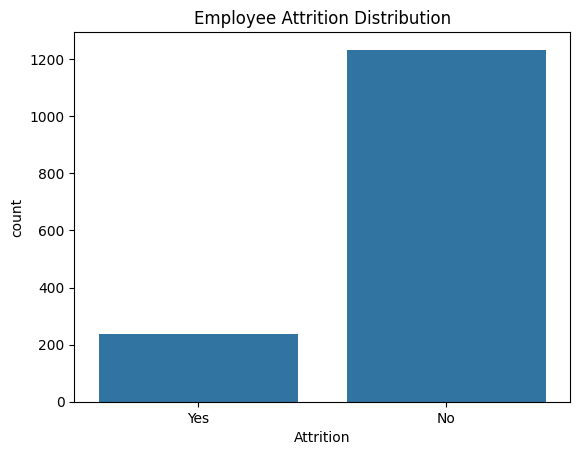

In [10]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

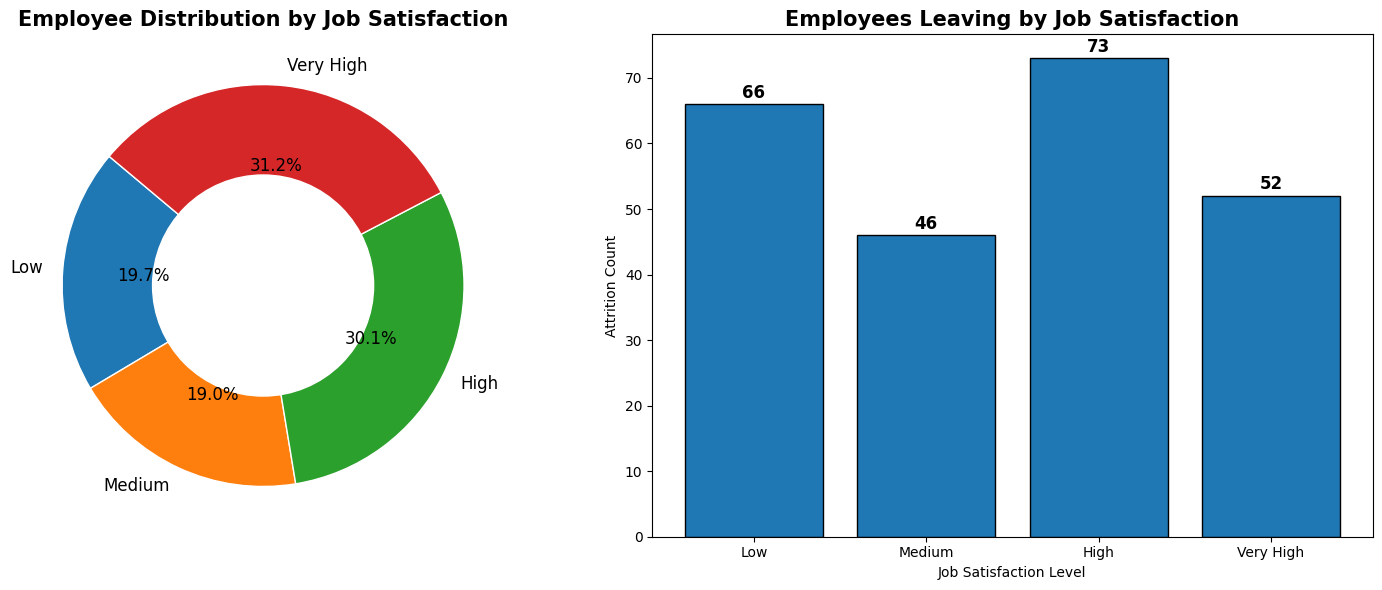

In [ ]:
# Job Satisfaction Analysis

fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Employee Distribution
job_counts = df['JobSatisfaction'].value_counts().sort_index()

labels = ['Low', 'Medium', 'High', 'Very High']

axes[0].pie(
    job_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor':'white'},
    textprops={'fontsize':12}
)

axes[0].set_title(
    'Employee Distribution by Job Satisfaction',
    fontsize=15,
    fontweight='bold'
)

# Donut effect
circle = plt.Circle((0,0), 0.55, color='white')
axes[0].add_artist(circle)

# Attrition by Job Satisfaction
attrition_df = df[df['Attrition'] == 'Yes']

attrition_counts = (
    attrition_df['JobSatisfaction']
    .value_counts()
    .sort_index()
)

bars = axes[1].bar(
    labels,
    attrition_counts.values,
    edgecolor='black'
)

axes[1].set_title(
    'Employees Leaving by Job Satisfaction',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel('Job Satisfaction Level')
axes[1].set_ylabel('Attrition Count')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{int(height)}',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

1. Most employees have high or very high job satisfaction in the company.
2. Employees with high job satisfaction still show a large number of resignations.
3. This means job satisfaction alone does not decide whether employees stay or leave.
4. Factors like overtime, salary, work-life balance, and career growth may also affect attrition.

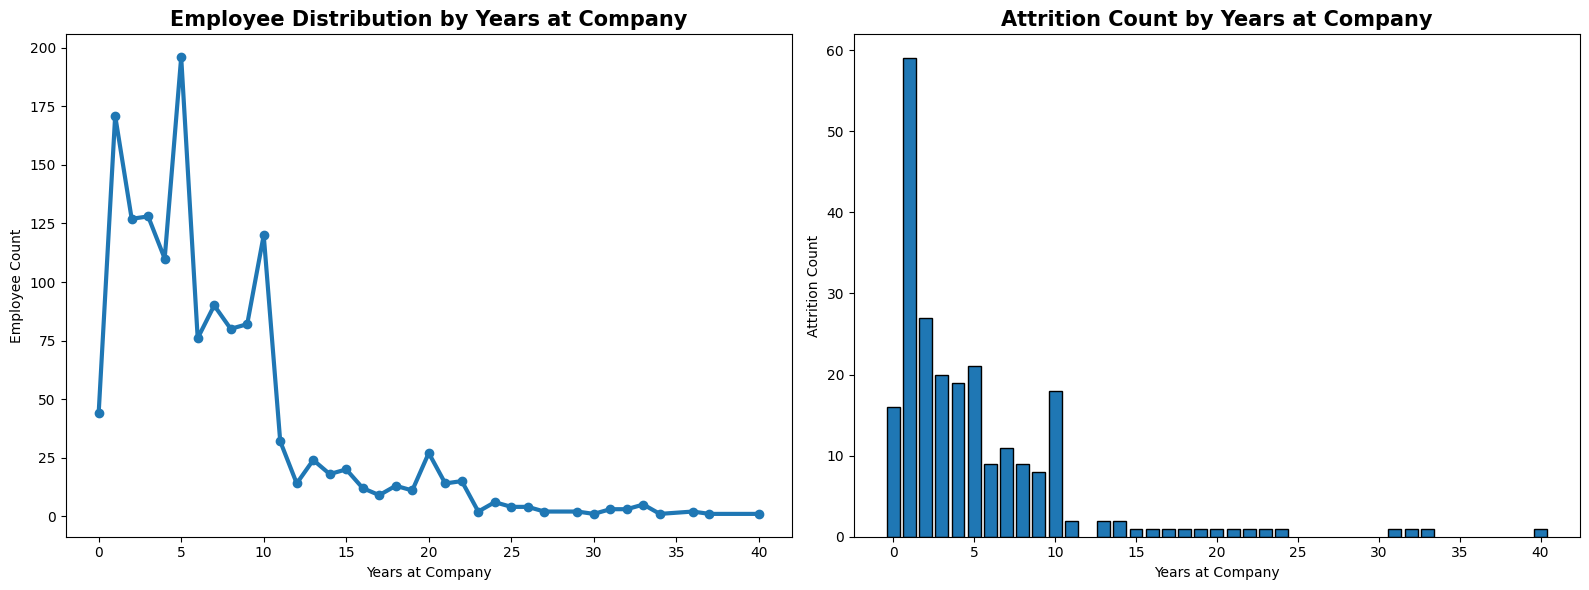

In [15]:
# Years at Company Analysis

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# -----------------------------------
# Employee Distribution by Years
# -----------------------------------
year_counts = df['YearsAtCompany'].value_counts().sort_index()

axes[0].plot(
    year_counts.index,
    year_counts.values,
    marker='o',
    linewidth=3
)

axes[0].set_title(
    'Employee Distribution by Years at Company',
    fontsize=15,
    fontweight='bold'
)

axes[0].set_xlabel('Years at Company')
axes[0].set_ylabel('Employee Count')

# -----------------------------------
# Attrition by Years at Company
# -----------------------------------
attrition_df = df[df['Attrition'] == 'Yes']

attrition_years = (
    attrition_df['YearsAtCompany']
    .value_counts()
    .sort_index()
)

axes[1].bar(
    attrition_years.index,
    attrition_years.values,
    edgecolor='black'
)

axes[1].set_title(
    'Attrition Count by Years at Company',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel('Years at Company')
axes[1].set_ylabel('Attrition Count')

plt.tight_layout()
plt.show()

1. Most employees have fewer years of experience in the company.
2. Attrition is higher among employees with lower years at the company.
3. Employees who stay longer tend to leave less frequently.
4. The company should focus more on retaining newly joined employees.



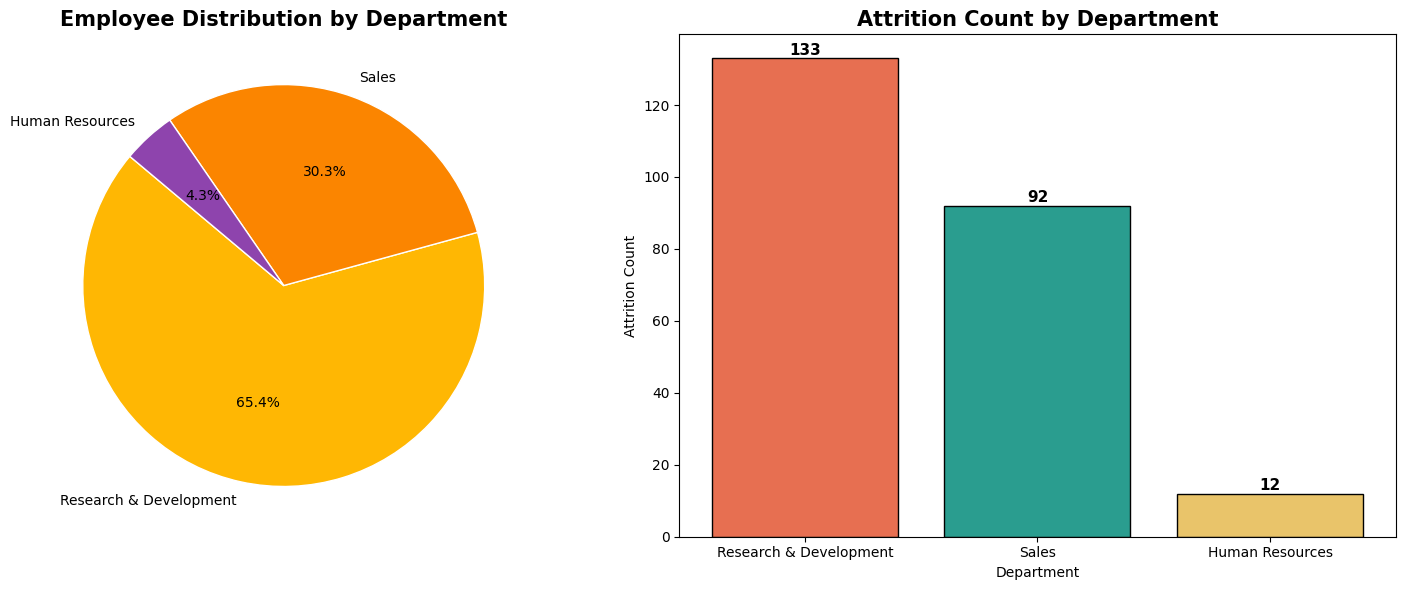

In [16]:
# Department Analysis with Different Colors

fig, axes = plt.subplots(1, 2, figsize=(15,6))

# -----------------------------------
# Employee Distribution by Department
# -----------------------------------
dept_counts = df['Department'].value_counts()

pie_colors = ['#FFB703', '#FB8500', '#8E44AD']

axes[0].pie(
    dept_counts.values,
    labels=dept_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=pie_colors,
    wedgeprops={'edgecolor':'white'}
)

axes[0].set_title(
    'Employee Distribution by Department',
    fontsize=15,
    fontweight='bold'
)

# -----------------------------------
# Attrition by Department
# -----------------------------------
attrition_df = df[df['Attrition'] == 'Yes']

dept_attrition = (
    attrition_df['Department']
    .value_counts()
)

bar_colors = ['#E76F51', '#2A9D8F', '#E9C46A']

bars = axes[1].bar(
    dept_attrition.index,
    dept_attrition.values,
    color=bar_colors,
    edgecolor='black'
)

axes[1].set_title(
    'Attrition Count by Department',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel('Department')
axes[1].set_ylabel('Attrition Count')

# Add values on bars
for bar in bars:
    height = bar.get_height()
    
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        int(height),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

1. Most employees work in the Research & Development department.
2. Research & Development has the highest employee attrition count.
3. The Sales department also shows a significant number of employees leaving.
4. Human Resources has the lowest number of employees and the lowest attrition count

In [17]:
# Drop constant/ID columns
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=drop_cols)

# Encode target
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("\nShape after preprocessing:", df_clean.shape)
df_clean.head()

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after preprocessing: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


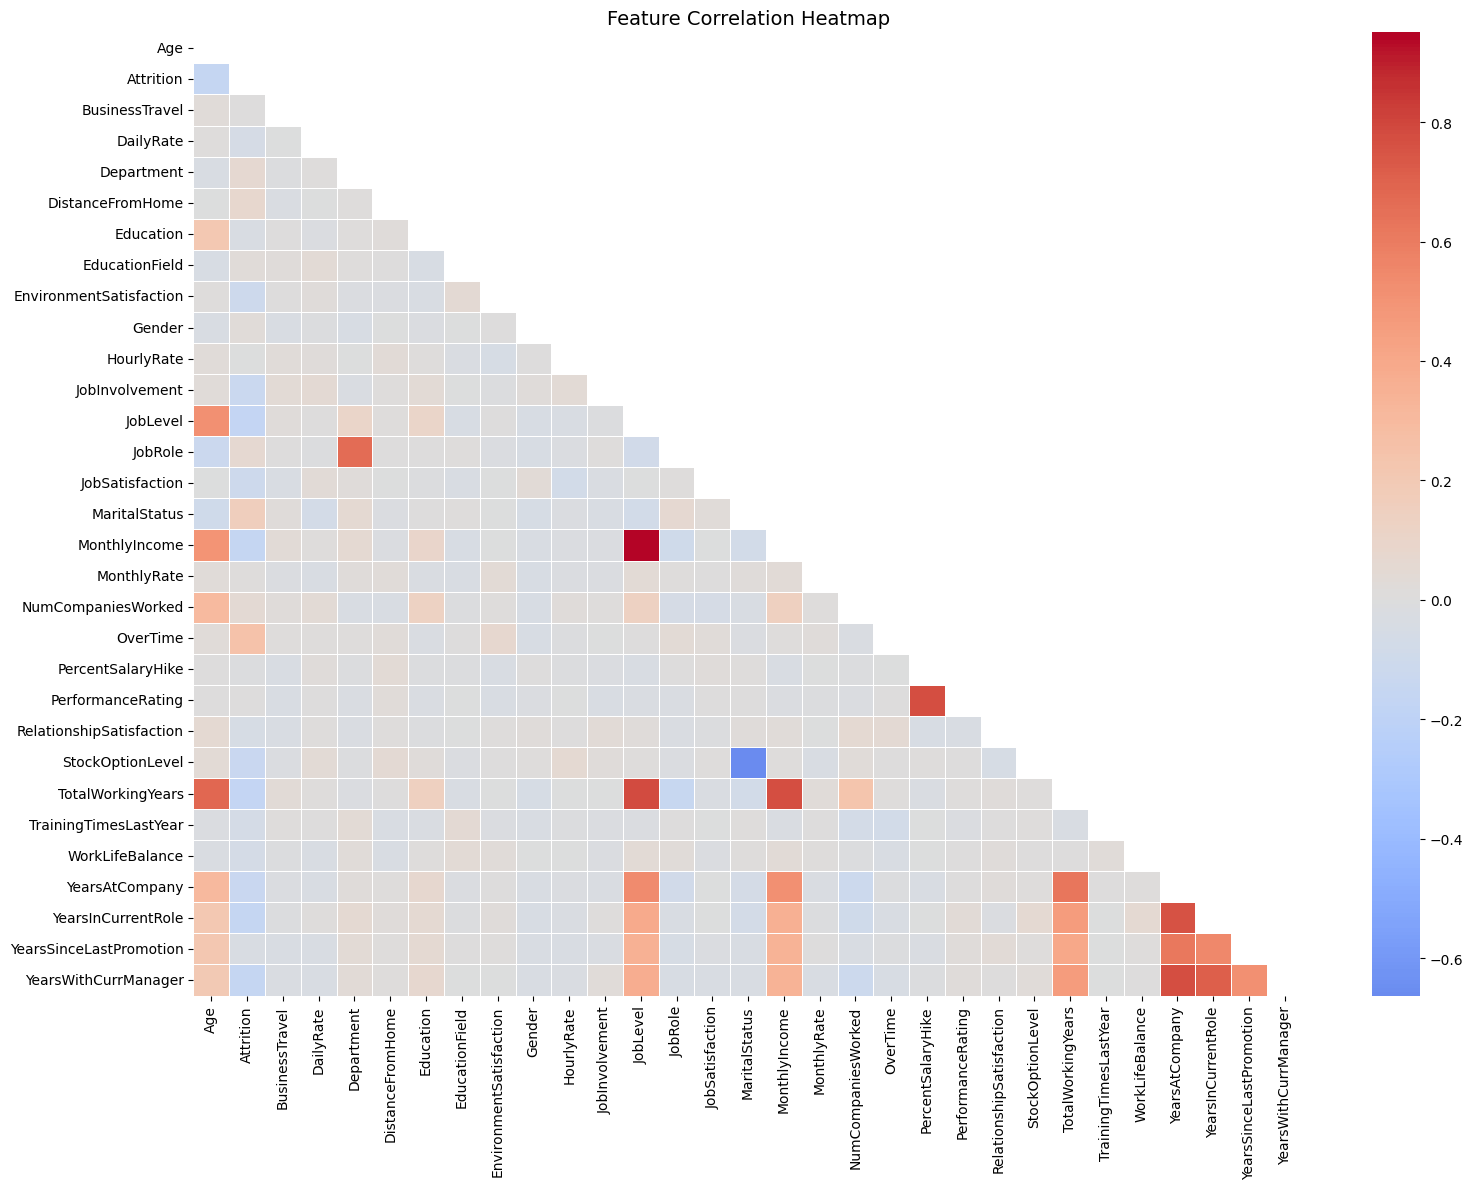

In [18]:
plt.figure(figsize=(16, 12))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

1. Most features have weak correlation with attrition, which means employee resignation depends on multiple factors together.
2. Overtime shows a positive correlation with attrition, indicating employees working overtime are more likely to leave.
3. Monthly income, job level, and total working years are strongly correlated with each other.
4. Years at company, years in current role, and years with current manager are highly related, showing employee experience factors are connected.



=== Chi-Square Scores (Top 15) ===
                Feature    Chi2_Score       P_Value
          MonthlyIncome 127922.293694  0.000000e+00
            MonthlyRate   1196.633553 3.287933e-262
              DailyRate    956.580494 4.923924e-210
      TotalWorkingYears    230.721618  4.149262e-52
         YearsAtCompany    142.100054  9.247066e-33
     YearsInCurrentRole    117.522596  2.205728e-27
   YearsWithCurrManager    110.671534  6.983363e-26
                    Age     84.155277  4.574015e-20
               OverTime     63.845067  1.345990e-15
       DistanceFromHome     63.772142  1.396748e-15
       StockOptionLevel     25.268826  4.987041e-07
               JobLevel     24.939242  5.916575e-07
          MaritalStatus     18.745657  1.493631e-05
                JobRole      9.004448  2.693233e-03
YearsSinceLastPromotion      7.601723  5.831253e-03


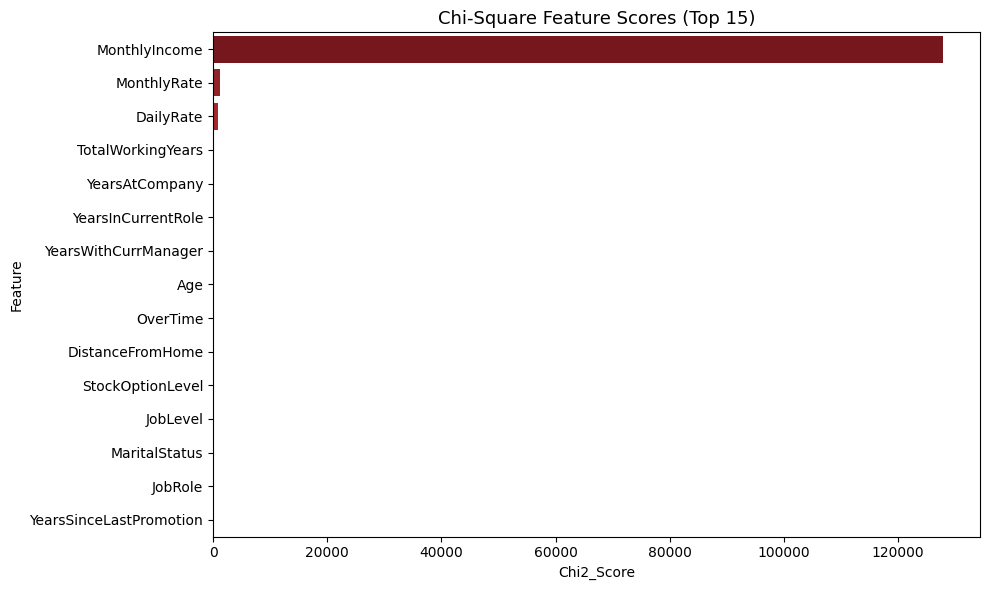

In [19]:
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

# Chi-square on all features (non-negative values)
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(np.abs(X), y)

chi2_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi2_Score': chi2_selector.scores_,
    'P_Value': chi2_selector.pvalues_
}).sort_values('Chi2_Score', ascending=False)

print("=== Chi-Square Scores (Top 15) ===")
print(chi2_scores.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=chi2_scores.head(15), x='Chi2_Score', y='Feature', palette='Reds_r')
plt.title('Chi-Square Feature Scores (Top 15)', fontsize=13)
plt.tight_layout()
plt.savefig('chi2_scores.png', dpi=150, bbox_inches='tight')
plt.show()

=== ANOVA F-Scores (Top 15) ===
                Feature   F_Score      P_Value
               OverTime 94.656457 1.009254e-21
      TotalWorkingYears 44.252491 4.061878e-11
               JobLevel 43.215344 6.795385e-11
          MaritalStatus 39.599763 4.106015e-10
     YearsInCurrentRole 38.838303 6.003186e-10
          MonthlyIncome 38.488819 7.147364e-10
                    Age 38.175887 8.356308e-10
   YearsWithCurrManager 36.712311 1.736987e-09
       StockOptionLevel 28.140501 1.301015e-07
         YearsAtCompany 27.001624 2.318872e-07
         JobInvolvement 25.241985 5.677065e-07
        JobSatisfaction 15.890004 7.043067e-05
EnvironmentSatisfaction 15.855209 7.172339e-05
       DistanceFromHome  8.968277 2.793060e-03
                JobRole  6.649672 1.001403e-02


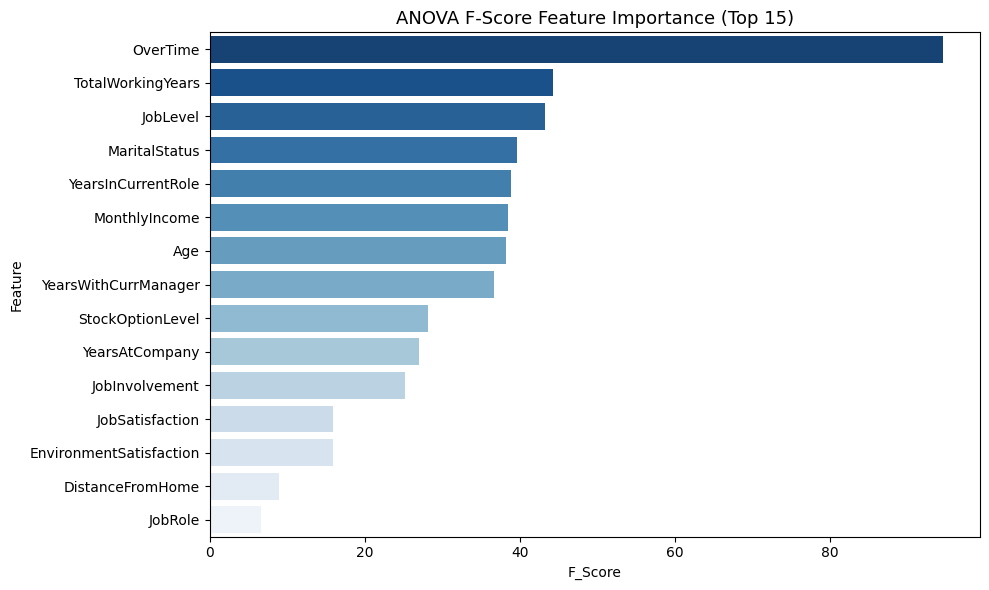

In [20]:
# ANOVA F-test
anova_selector = SelectKBest(f_classif, k='all')
anova_selector.fit(X, y)

anova_scores = pd.DataFrame({
    'Feature': X.columns,
    'F_Score': anova_selector.scores_,
    'P_Value': anova_selector.pvalues_
}).sort_values('F_Score', ascending=False)

print("=== ANOVA F-Scores (Top 15) ===")
print(anova_scores.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=anova_scores.head(15), x='F_Score', y='Feature', palette='Blues_r')
plt.title('ANOVA F-Score Feature Importance (Top 15)', fontsize=13)
plt.tight_layout()
plt.savefig('anova_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Combine top features from both methods
top_chi2 = set(chi2_scores.head(15)['Feature'].tolist())
top_anova = set(anova_scores.head(15)['Feature'].tolist())
top_features = list(top_chi2.union(top_anova))

print(f"Total selected features: {len(top_features)}")
print("Features:", top_features)

X_selected = X[top_features]

Total selected features: 18
Features: ['MaritalStatus', 'JobSatisfaction', 'EnvironmentSatisfaction', 'DailyRate', 'YearsWithCurrManager', 'OverTime', 'TotalWorkingYears', 'DistanceFromHome', 'Age', 'StockOptionLevel', 'MonthlyRate', 'MonthlyIncome', 'YearsAtCompany', 'JobLevel', 'JobRole', 'JobInvolvement', 'YearsSinceLastPromotion', 'YearsInCurrentRole']
